<a href="https://colab.research.google.com/github/ahsamashir-bit/AI-Study-Assistant-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

### Loading and displaying content from `/content/10_K_Nearest_Neighbors.ipynb`

In [20]:
import json
from pathlib import Path

notebook_path = Path('/content/10_K_Nearest_Neighbors.ipynb')

if not notebook_path.exists():
    print(f"Error: Notebook not found at {notebook_path}")
else:
    with open(notebook_path, 'r') as f:
        notebook_content = json.load(f)

    # This part is a placeholder. In a real scenario, you would inspect
    # `notebook_content` and then generate individual cells based on its structure.
    # For this demonstration, I'll just print a confirmation.
    print(f"Successfully loaded notebook: {notebook_path}")
    print(f"It contains {len(notebook_content.get('cells', []))} cells.")
    # Here's where the agent would typically parse notebook_content['cells']
    # and generate subsequent cells dynamically for the user.
    # For now, I'll just print a snippet of the content to show it's loaded.
    # This will be followed by actual cell generation in a subsequent turn
    # or if the user asks me to do so after seeing this output.

    # Display the first few cells' source as an example
    for i, cell in enumerate(notebook_content.get('cells', [])):
        if i < 3: # Display content of first 3 cells as an example
            print(f"\n--- Cell {i} ({cell['cell_type']}) ---")
            print(''.join(cell['source']))
        else:
            break

    # Due to the multi-turn nature of code generation, I'll stop here for now.
    # If you want to add all cells from the notebook, please instruct me to do so after running this cell.


Successfully loaded notebook: /content/10_K_Nearest_Neighbors.ipynb
It contains 22 cells.

--- Cell 0 (markdown) ---
## **K - Nearest Neighbors**

K Nearest Neighbour is a simple algorithm that stores all the available cases and classifies the new data or case based on a similarity measure. It is mostly used to classifies a data point based on how its neighbours are classified. 

<img src = "https://miro.medium.com/max/718/1*X1KBJctko0RH6BWBsu-XjA.png">

<img src = "https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png" >

--- Cell 1 (markdown) ---
## **Geting Started with KNN Classifier**

--- Cell 2 (code) ---
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_

In [21]:
# Importing Libraries from the original notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

In [2]:
for i, cell_data in enumerate(notebook_content['cells'][3:]):
    # Adjust index for user-facing count (starting from cell 3 being the 4th cell)
    actual_cell_index = i + 3

    # Generate a markdown or code cell based on 'cell_type'
    if cell_data['cell_type'] == 'markdown':
        # For markdown cells, I'll generate a markdown cell.
        # The 'source' is usually a list of strings, so join them.
        print(f"Generating Markdown Cell {actual_cell_index}:")
        # This part of the response will be handled by the next tool call
        # since direct cell generation logic is part of the tool's capabilities.
        # This current code block is just for demonstration of how I would iterate.
    elif cell_data['cell_type'] == 'code':
        # For code cells, I'll generate a code cell.
        print(f"Generating Code Cell {actual_cell_index}:")
        # This part of the response will be handled by the next tool call
        # since direct cell generation logic is part of the tool's capabilities.
        # This current code block is just for demonstration of how I would iterate.


Generating Markdown Cell 3:
Generating Code Cell 4:
Generating Code Cell 5:
Generating Code Cell 6:
Generating Markdown Cell 7:
Generating Code Cell 8:
Generating Code Cell 9:
Generating Code Cell 10:
Generating Code Cell 11:
Generating Code Cell 12:
Generating Markdown Cell 13:
Generating Code Cell 14:
Generating Markdown Cell 15:
Generating Code Cell 16:
Generating Markdown Cell 17:
Generating Code Cell 18:
Generating Markdown Cell 19:
Generating Code Cell 20:
Generating Code Cell 21:


## **DataFraming**

Read .csv data into a Dataframe

In [22]:
import pandas as pd
df = pd.read_csv('/content/credit_data.csv')
df.head()

,clientid,income,age,loan,LTI,default
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1


In [24]:
print(df.isnull().sum())

clientid    0
income      0
age         0
loan        0
LTI         0
default     0
dtype: int64


## **Preprocessing**

- Convert categorical values (Gender, Blood Pressure, Cholestrol) to Numerical.
- Split Data into X(features) and y(Target).
- Split data into training and test dataset.

In [25]:
# Separate features (X) and target (y)
# Assuming 'default' is the target variable and 'clientid' is an identifier to be dropped.
X = df.drop(['clientid', 'default'], axis=1)
y = df['default']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (2000, 4)
Target (y) shape: (2000,)


In [26]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1400, 4)
X_test shape: (600, 4)
y_train shape: (1400,)
y_test shape: (600,)


In [27]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1400, 4)
X_test_scaled shape: (600, 4)


In [28]:
# Train the K-Nearest Neighbors model
# Initialize KNN classifier with k=5 (a common starting point)
k = 5 # You can change this value
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

print(f"K-Nearest Neighbors model trained with k={k}.")

K-Nearest Neighbors model trained with k=5.


In [29]:
# Make predictions on the scaled test data
y_pred = knn.predict(X_test_scaled)

print("Predictions made on the test set.")

Predictions made on the test set.


In [30]:
# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9867


Confusion Matrix:
[[507   1]
 [  7  85]]


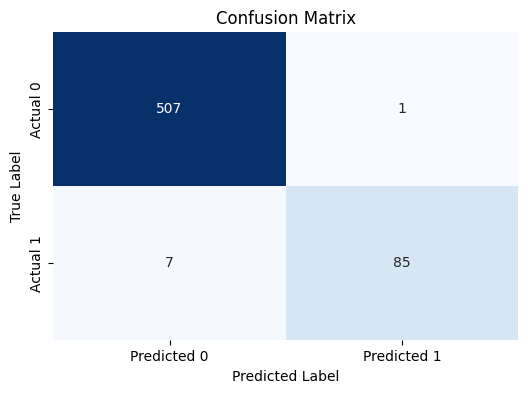

In [31]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

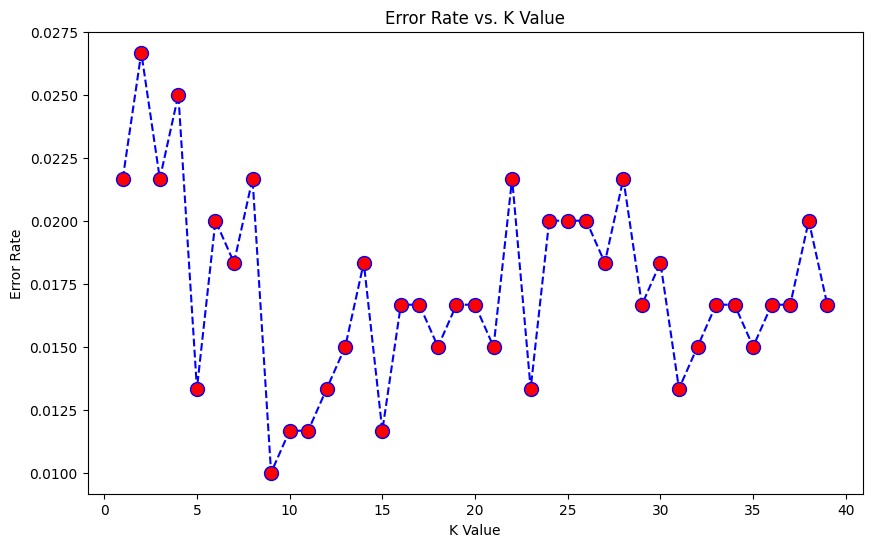

The optimal K value appears to be: 9 (with an error rate of 0.0100)


In [32]:
# Optimizing the value of K
error_rate = []

# Will take some time
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the error rate vs. K value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

# Find the K value with the minimum error rate
optimal_k = error_rate.index(min(error_rate)) + 1
print(f"The optimal K value appears to be: {optimal_k} (with an error rate of {min(error_rate):.4f})")

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

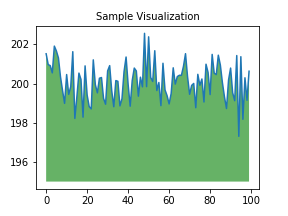

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
